In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dadapy.metric_comparisons import MetricComparisons
from utilities import *

In [2]:
def compute_rank_matrix(data, metric="euclidean"):
    """
    Computes the rank matrix of the input data.

    Args:
        data (np.ndarray or list(list(float))): dataset of shape (N,D), with N points and D features

        metric (str, default="euclidean"): name of the distance employed

    Returns:
        rank_matrix (np.ndarray): array of shape (N,N), with ij-th element corresponding to the rank
                                  order of point j with respect to i. Diagonal elements are set to
                                  np.infty; the remaining entries have integer values between 1 and N-1
    """
    pairwise_dist = squareform(pdist(data, metric=metric))
    pairwise_dist = pairwise_dist.astype('float')

    np.fill_diagonal(pairwise_dist, np.infty)
    rank_matrix = rankdata(pairwise_dist, method='average', axis=1)
    #np.fill_diagonal(rank_matrix, np.infty)

    return rank_matrix

In [11]:
def compute_info_imbalance_perm(data_A, data_B, k_A=1, k_B=1, metric="euclidean"):

    if data_A.shape[0] != data_B.shape[0]:
        raise ValueError("Number of points must be the same in the two representations!")
    N = data_A.shape[0]
    rank_matrix_A = compute_rank_matrix(data_A, metric=metric)
    rank_matrix_B = compute_rank_matrix(data_B, metric=metric)

    new_indices = np.random.choice(np.arange(N), replace=False, size=N)
    rank_matrix_A = rank_matrix_A[new_indices][:,new_indices]

    # Find the nn indices in each space
    nns_A = nns_index_array(rank_matrix_A, k=k_A+1)[:,1:]
    nns_B = nns_index_array(rank_matrix_B, k=k_B+1)[:,1:]

    # Find conditional ranks in two spaces
    conditional_ranks_B = np.zeros((N, k_A))
    for i_point in range(N):
        rank_B = rank_matrix_B[i_point][nns_A[i_point]]
        conditional_ranks_B[i_point] = rank_B
    conditional_ranks_B = conditional_ranks_B.flatten()

    conditional_ranks_A = np.zeros((N, k_B))
    for i_point in range(N):
        rank_A = rank_matrix_A[i_point][nns_B[i_point]]
        conditional_ranks_A[i_point] = rank_A
    conditional_ranks_A = conditional_ranks_A.flatten()

    # The information imbalances:
    imb_A_to_B = 2/N * np.mean(conditional_ranks_B)
    imb_B_to_A = 2/N * np.mean(conditional_ranks_A)

    return imb_A_to_B, imb_B_to_A

In [12]:
# create test dataset
N = 100

cov = np.identity(2)
cov[-1, -1] = 0.01**2 # variance along z is much smaller!
mean = np.zeros(2)
X = np.random.multivariate_normal(mean = mean, cov = cov, size = (N))

In [13]:
# permute ranks
n_perms = 1000
imbs1 = np.zeros(n_perms)

for i in range(n_perms):
    imb, _ = compute_info_imbalance_perm(X[:,0].reshape((-1,1)), X[:,1].reshape((-1,1)))
    imbs1[i] = imb

In [14]:
# permute points
n_perms = 1000
imbs2 = np.zeros(n_perms)

for i in range(n_perms):#100):
    X0 = X[:,0]
    np.random.shuffle(X0)
    d = MetricComparisons(np.column_stack((X0,X[:,1])), maxk=X.shape[0]-1)
    imb, _ = d.return_inf_imb_two_selected_coords(coords1=[0], coords2=[1], k=1)
    imbs2[i] = imb

(array([0.06, 0.17, 0.06, 0.44, 0.55, 1.  , 1.6 , 2.16, 3.43, 4.15, 5.2 ,
        5.53, 6.52, 5.53, 4.98, 4.64, 2.82, 2.27, 2.16, 1.22, 0.5 , 0.17,
        0.06, 0.06, 0.06]),
 array([0.77, 0.79, 0.81, 0.83, 0.85, 0.87, 0.88, 0.9 , 0.92, 0.94, 0.96,
        0.97, 0.99, 1.01, 1.03, 1.05, 1.06, 1.08, 1.1 , 1.12, 1.14, 1.15,
        1.17, 1.19, 1.21, 1.23]),
 <BarContainer object of 25 artists>)

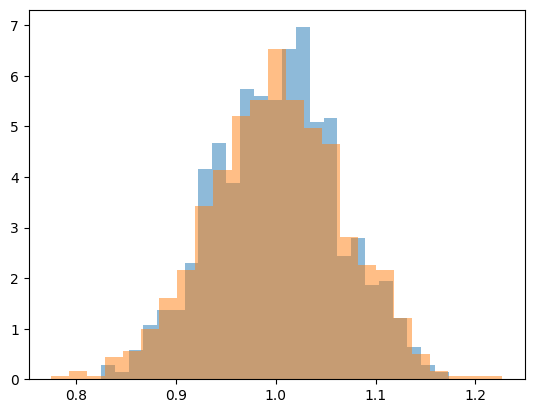

In [15]:
plt.hist(imbs1, bins=25, alpha=0.5, density=True)
plt.hist(imbs2, bins=25, alpha=0.5, density=True)